# Breast Cancer Wisconsin (Diagnostic) — Data Exploration and Cleaning

This notebook prepares the **Cancer Disease** module of the Multi-Disease Machine Learning System.

## Objective

Build a clean binary-classification dataset for predicting whether a breast tumor is:

- `0` = Benign
- `1` = Malignant

## Uploaded dataset

The dataset contains **569 records** and **33 CSV columns**.

Important preprocessing decisions:

- `id` is removed because it is only an identifier.
- `Unnamed: 32` is removed because it is completely empty.
- `diagnosis` is converted from `B/M` to a binary target named `cancer_diagnosis`.
- All **30 diagnostic measurement features** are retained for model training.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

# Detect the project root whether the notebook starts from
# the project folder or from the notebooks folder.
current_folder = Path.cwd()

project_root = (
    current_folder.parent
    if current_folder.name == "notebooks"
    else current_folder
)

raw_data_path = (
    project_root
    / "data"
    / "raw"
    / "cancer_disease.csv"
)

processed_data_path = (
    project_root
    / "data"
    / "processed"
    / "cancer_disease_clean.csv"
)

figures_folder = (
    project_root
    / "reports"
    / "figures"
)

processed_data_path.parent.mkdir(parents=True, exist_ok=True)
figures_folder.mkdir(parents=True, exist_ok=True)

print("Dataset path:", raw_data_path)
print("File exists:", raw_data_path.exists())

if not raw_data_path.exists():
    raise FileNotFoundError(
        "Place cancer_disease.csv inside data/raw before running this notebook."
    )

Dataset path: d:\1. My Files in Collage\5th Level\AI\Multi_Disease_ML_System\data\raw\cancer_disease.csv
File exists: True


In [2]:
# Load the raw dataset
cancer_raw = pd.read_csv(raw_data_path)

print("Dataset loaded successfully.")
print("Dataset shape:", cancer_raw.shape)

print("\nColumns:")
print(cancer_raw.columns.tolist())

print("\nData types:")
print(cancer_raw.dtypes)

display(cancer_raw.head())

Dataset loaded successfully.
Dataset shape: (569, 33)

Columns:
['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se', 'fractal_dimension_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst', 'Unnamed: 32']

Data types:
id                           int64
diagnosis                      str
radius_mean                float64
texture_mean               float64
perimeter_mean             float64
area_mean                  float64
smoothness_mean            float64
compactness_mean           float64
concavity_mean             float64
concave points_mean        f

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [3]:
# Initial data-quality summary
quality_summary = pd.DataFrame(
    {
        "Data Type": cancer_raw.dtypes.astype(str),
        "Missing Values": cancer_raw.isnull().sum(),
        "Missing Percentage": (
            cancer_raw.isnull().mean().mul(100).round(2)
        ),
        "Unique Values": cancer_raw.nunique(dropna=True),
    }
)

display(
    quality_summary.sort_values(
        ["Missing Values", "Unique Values"],
        ascending=[False, False],
    )
)

print("Duplicated complete rows:", cancer_raw.duplicated().sum())

if "id" in cancer_raw.columns:
    print("Unique IDs:", cancer_raw["id"].nunique())

print("\nDiagnosis distribution:")
print(
    cancer_raw["diagnosis"]
    .value_counts(dropna=False)
)

,Data Type,Missing Values,Missing Percentage,Unique Values
Unnamed: 32,float64,569,100.0,0
id,int64,0,0.0,569
smoothness_se,float64,0,0.0,547
fractal_dimension_se,float64,0,0.0,545
area_worst,float64,0,0.0,544
concave points_mean,float64,0,0.0,542
compactness_se,float64,0,0.0,541
radius_se,float64,0,0.0,540
area_mean,float64,0,0.0,539
concavity_worst,float64,0,0.0,539


Duplicated complete rows: 0
Unique IDs: 569

Diagnosis distribution:
diagnosis
B    357
M    212
Name: count, dtype: int64


## Dataset structure

The diagnostic features describe characteristics of cell nuclei obtained from a breast mass.

The 30 numerical predictors are grouped into:

1. **Mean measurements** — 10 features
2. **Standard-error measurements** — 10 features
3. **Worst/largest measurements** — 10 features

The same base measurements appear in each group:

- radius
- texture
- perimeter
- area
- smoothness
- compactness
- concavity
- concave points
- symmetry
- fractal dimension


In [4]:
# Inspect raw target labels and empty columns
print("Unique diagnosis labels:")
print(cancer_raw["diagnosis"].unique())

completely_empty_columns = [
    column
    for column in cancer_raw.columns
    if cancer_raw[column].isnull().all()
]

print("\nCompletely empty columns:")
print(completely_empty_columns)

Unique diagnosis labels:
<ArrowStringArray>
['M', 'B']
Length: 2, dtype: str

Completely empty columns:
['Unnamed: 32']


## Cleaning strategy

1. Standardize column names.
2. Replace spaces with underscores in feature names.
3. Remove `id`.
4. Remove the completely empty `Unnamed: 32` column.
5. Convert `diagnosis`:
   - `B` → `0`
   - `M` → `1`
6. Verify that all 30 model predictors are numerical.
7. Check missing values, duplicates, and suspicious values.
8. Save the processed CSV for model training.


In [5]:
# Create an independent working copy
cancer_clean = cancer_raw.copy()

# Normalize column names
cancer_clean.columns = [
    str(column)
    .strip()
    .lower()
    .replace(" ", "_")
    for column in cancer_clean.columns
]

# Remove identifier and empty columns
drop_columns = [
    column
    for column in [
        "id",
        "unnamed:_32",
        "unnamed_32",
    ]
    if column in cancer_clean.columns
]

cancer_clean = cancer_clean.drop(
    columns=drop_columns
)

# Normalize the target
cancer_clean["diagnosis"] = (
    cancer_clean["diagnosis"]
    .astype("string")
    .str.strip()
    .str.upper()
)

target_mapping = {
    "B": 0,
    "M": 1,
}

cancer_clean["cancer_diagnosis"] = (
    cancer_clean["diagnosis"]
    .map(target_mapping)
)

if cancer_clean["cancer_diagnosis"].isnull().any():
    invalid_labels = cancer_clean.loc[
        cancer_clean["cancer_diagnosis"].isnull(),
        "diagnosis",
    ].unique()

    raise ValueError(
        f"Unexpected diagnosis labels: {invalid_labels}"
    )

cancer_clean["cancer_diagnosis"] = (
    cancer_clean["cancer_diagnosis"]
    .astype("int8")
)

cancer_clean = cancer_clean.drop(
    columns=["diagnosis"]
)

print("Cleaned dataset shape:", cancer_clean.shape)
print("Columns after cleaning:", len(cancer_clean.columns))

display(cancer_clean.head())

Cleaned dataset shape: (569, 31)
Columns after cleaning: 31


,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave_points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst,cancer_diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,1
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,1
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,1
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,1
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,1


In [6]:
# Define predictors and target
target_column = "cancer_diagnosis"

feature_columns = [
    column
    for column in cancer_clean.columns
    if column != target_column
]

# Ensure all predictors are numerical
for column in feature_columns:
    cancer_clean[column] = pd.to_numeric(
        cancer_clean[column],
        errors="coerce",
    )

print("Number of predictors:", len(feature_columns))
print("Target column:", target_column)

if len(feature_columns) != 30:
    raise ValueError(
        f"Expected 30 diagnostic predictors, found {len(feature_columns)}."
    )

non_numeric_features = [
    column
    for column in feature_columns
    if not pd.api.types.is_numeric_dtype(
        cancer_clean[column]
    )
]

print("Non-numeric predictors:", non_numeric_features)
print(
    "Total missing predictor values:",
    cancer_clean[feature_columns]
    .isnull()
    .sum()
    .sum(),
)

if non_numeric_features:
    raise ValueError(
        f"Unexpected non-numeric predictors: {non_numeric_features}"
    )

Number of predictors: 30
Target column: cancer_diagnosis
Non-numeric predictors: []
Total missing predictor values: 0


In [7]:
# Final quality validation
final_quality_summary = pd.DataFrame(
    {
        "Data Type": cancer_clean.dtypes.astype(str),
        "Missing Values": cancer_clean.isnull().sum(),
        "Missing Percentage": (
            cancer_clean.isnull().mean().mul(100).round(2)
        ),
        "Unique Values": cancer_clean.nunique(dropna=True),
    }
)

display(final_quality_summary)

print(
    "Duplicated cleaned rows:",
    cancer_clean.duplicated().sum(),
)

print("\nFinal target distribution:")
target_counts = (
    cancer_clean[target_column]
    .value_counts()
    .sort_index()
)

print(target_counts)

print("\nFinal target percentages:")
print(
    target_counts
    .div(target_counts.sum())
    .mul(100)
    .round(2)
)

,Data Type,Missing Values,Missing Percentage,Unique Values
radius_mean,float64,0,0.0,456
texture_mean,float64,0,0.0,479
perimeter_mean,float64,0,0.0,522
area_mean,float64,0,0.0,539
smoothness_mean,float64,0,0.0,474
compactness_mean,float64,0,0.0,537
concavity_mean,float64,0,0.0,537
concave_points_mean,float64,0,0.0,542
symmetry_mean,float64,0,0.0,432
fractal_dimension_mean,float64,0,0.0,499


Duplicated cleaned rows: 0

Final target distribution:
cancer_diagnosis
0    357
1    212
Name: count, dtype: int64

Final target percentages:
cancer_diagnosis
0    62.74
1    37.26
Name: count, dtype: float64


In [8]:
# Summary statistics for numerical predictors
descriptive_statistics = (
    cancer_clean[feature_columns]
    .describe()
    .T
)

display(
    descriptive_statistics[
        [
            "mean",
            "std",
            "min",
            "25%",
            "50%",
            "75%",
            "max",
        ]
    ].round(4)
)

,mean,std,min,25%,50%,75%,max
radius_mean,14.1273,3.5240,6.9810,11.7000,13.3700,15.7800,28.1100
texture_mean,19.2896,4.3010,9.7100,16.1700,18.8400,21.8000,39.2800
perimeter_mean,91.9690,24.2990,43.7900,75.1700,86.2400,104.1000,188.5000
area_mean,654.8891,351.9141,143.5000,420.3000,551.1000,782.7000,2501.0000
smoothness_mean,0.0964,0.0141,0.0526,0.0864,0.0959,0.1053,0.1634
compactness_mean,0.1043,0.0528,0.0194,0.0649,0.0926,0.1304,0.3454
concavity_mean,0.0888,0.0797,0.0000,0.0296,0.0615,0.1307,0.4268
concave_points_mean,0.0489,0.0388,0.0000,0.0203,0.0335,0.0740,0.2012
symmetry_mean,0.1812,0.0274,0.1060,0.1619,0.1792,0.1957,0.3040
fractal_dimension_mean,0.0628,0.0071,0.0500,0.0577,0.0615,0.0661,0.0974


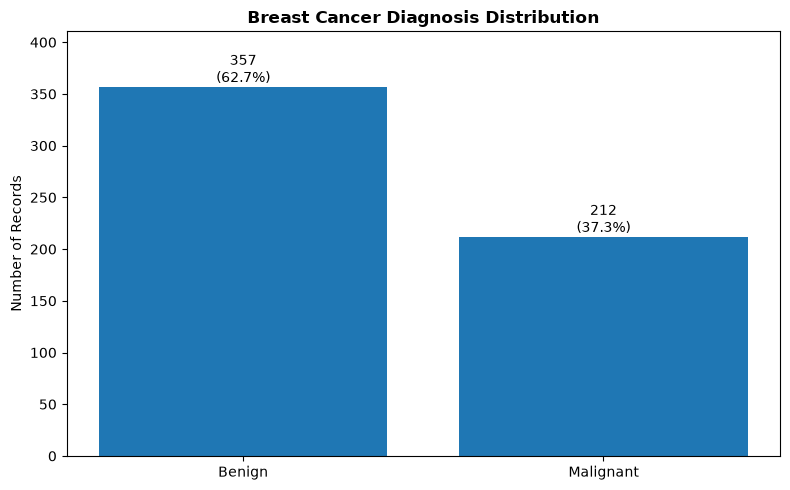

Saved: d:\1. My Files in Collage\5th Level\AI\Multi_Disease_ML_System\reports\figures\cancer_target_distribution.png


In [9]:
# Target distribution visualization
target_counts = (
    cancer_clean[target_column]
    .value_counts()
    .sort_index()
)

labels = [
    "Benign",
    "Malignant",
]

percentages = (
    target_counts
    .div(target_counts.sum())
    .mul(100)
)

plt.figure(figsize=(8, 5))

bars = plt.bar(
    labels,
    target_counts.values,
)

for bar, count, percentage in zip(
    bars,
    target_counts.values,
    percentages.values,
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{count}\n({percentage:.1f}%)",
        ha="center",
        va="bottom",
    )

plt.title(
    "Breast Cancer Diagnosis Distribution",
    fontweight="bold",
)
plt.ylabel("Number of Records")
plt.ylim(
    0,
    target_counts.max() * 1.15,
)
plt.tight_layout()

target_figure_path = (
    figures_folder
    / "cancer_target_distribution.png"
)

plt.savefig(
    target_figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print("Saved:", target_figure_path)

,Correlation with cancer target
smoothness_se,-0.0670
fractal_dimension_mean,-0.0128
texture_se,-0.0083
symmetry_se,-0.0065
fractal_dimension_se,0.0780
concavity_se,0.2537
compactness_se,0.2930
fractal_dimension_worst,0.3239
symmetry_mean,0.3305
smoothness_mean,0.3586


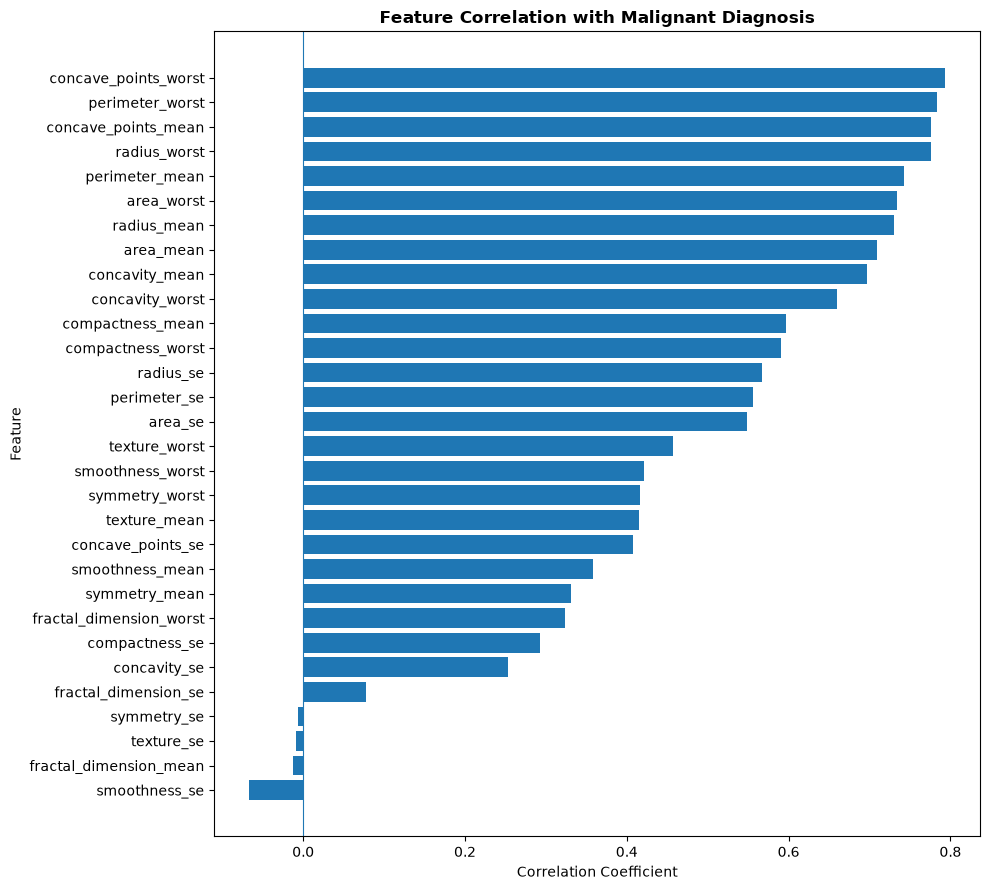

Saved: d:\1. My Files in Collage\5th Level\AI\Multi_Disease_ML_System\reports\figures\cancer_feature_correlations.png


In [10]:
# Correlation of each feature with the binary cancer target
target_correlations = (
    cancer_clean
    .corr(numeric_only=True)[target_column]
    .drop(target_column)
    .sort_values()
)

display(
    target_correlations
    .to_frame("Correlation with cancer target")
    .round(4)
)

plt.figure(figsize=(10, 9))

plt.barh(
    target_correlations.index,
    target_correlations.values,
)

plt.axvline(
    0,
    linewidth=0.8,
)

plt.title(
    "Feature Correlation with Malignant Diagnosis",
    fontweight="bold",
)
plt.xlabel("Correlation Coefficient")
plt.ylabel("Feature")
plt.tight_layout()

correlation_figure_path = (
    figures_folder
    / "cancer_feature_correlations.png"
)

plt.savefig(
    correlation_figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print("Saved:", correlation_figure_path)

In [11]:
# Identify the strongest absolute correlations
top_correlated_features = (
    target_correlations
    .abs()
    .sort_values(ascending=False)
    .head(10)
    .index
    .tolist()
)

top_feature_table = pd.DataFrame(
    {
        "Feature": top_correlated_features,
        "Correlation": [
            target_correlations[feature]
            for feature in top_correlated_features
        ],
        "Absolute Correlation": [
            abs(target_correlations[feature])
            for feature in top_correlated_features
        ],
    }
)

display(
    top_feature_table.style.format(
        {
            "Correlation": "{:.4f}",
            "Absolute Correlation": "{:.4f}",
        }
    )
)

,Feature,Correlation,Absolute Correlation
0,concave_points_worst,0.7936,0.7936
1,perimeter_worst,0.7829,0.7829
2,concave_points_mean,0.7766,0.7766
3,radius_worst,0.7765,0.7765
4,perimeter_mean,0.7426,0.7426
5,area_worst,0.7338,0.7338
6,radius_mean,0.7300,0.7300
7,area_mean,0.7090,0.7090
8,concavity_mean,0.6964,0.6964
9,concavity_worst,0.6596,0.6596


In [12]:
# Compare important feature distributions by diagnosis
selected_features = [
    "radius_mean",
    "texture_mean",
    "perimeter_mean",
    "area_mean",
    "concavity_mean",
    "concave_points_mean",
    "radius_worst",
    "perimeter_worst",
    "area_worst",
    "concave_points_worst",
]

available_selected_features = [
    feature
    for feature in selected_features
    if feature in cancer_clean.columns
]

group_summary = (
    cancer_clean
    .groupby(target_column)[available_selected_features]
    .agg(["mean", "median", "std"])
)

display(group_summary.round(4))

radius_mean                 texture_mean                 \
                        mean  median     std         mean median     std   
cancer_diagnosis                                                           
0                    12.1465  12.200  1.7805      17.9148  17.39  3.9951   
1                    17.4628  17.325  3.2040      21.6049  21.46  3.7795   

                 perimeter_mean                  area_mean                   \
                           mean  median      std      mean median       std   
cancer_diagnosis                                                              
0                       78.0754   78.18  11.8074  462.7902  458.4  134.2871   
1                      115.3654  114.20  21.8547  978.3764  932.0  367.9380   

                 concavity_mean                 concave_points_mean          \
                           mean  median     std                mean  median   
cancer_diagnosis                                                              
0                        0.0461  0.0371  0.0434              0.0257  0.0234   
1                        0.1608  0.1513  0.0750              0.0880  0.0863   

                         radius_worst                perimeter_worst          \
                     std         mean median     std            mean  median   
cancer_diagnosis                                                               
0                 0.0159      13.3798  13.35  1.9814         87.0059   86.92   
1                 0.0344      21.1348  20.59  4.2836        141.3703  138.00   

                          area_worst                   concave_points_worst  \
                      std       mean  median       std                 mean   
cancer_diagnosis                                                              
0                 13.5271   558.8994   547.4  163.6014               0.0744   
1                 29.4571  1422.2863  1303.0  597.9677               0.1822   

                                  
                  median     std  
cancer_diagnosis                  
0                 0.0743  0.0358  
1                 0.1820  0.0463

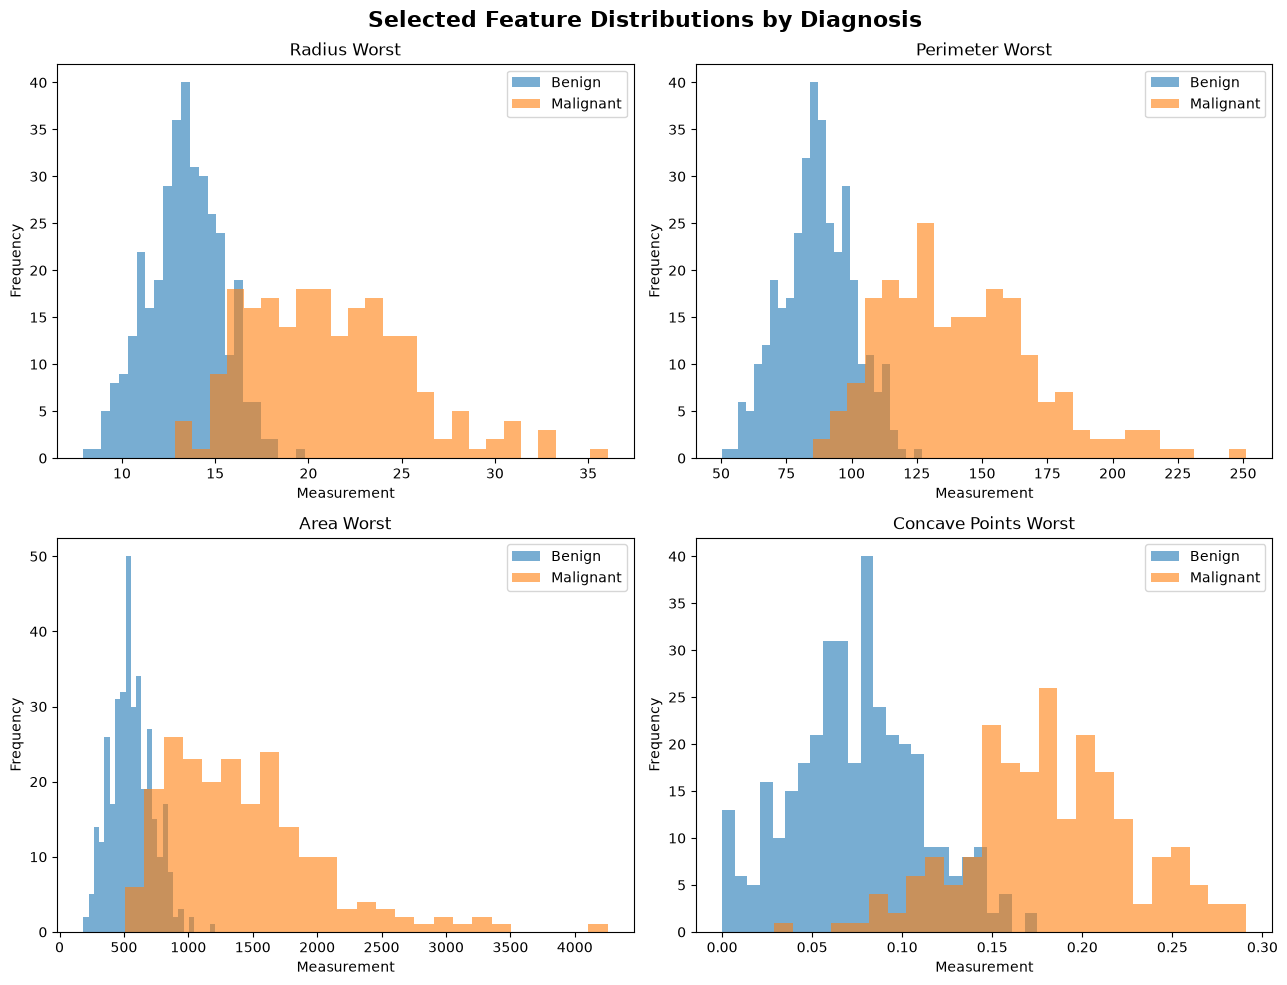

Saved: d:\1. My Files in Collage\5th Level\AI\Multi_Disease_ML_System\reports\figures\cancer_feature_distributions.png


In [13]:
# Visualize a few clinically important measurements
comparison_features = [
    "radius_worst",
    "perimeter_worst",
    "area_worst",
    "concave_points_worst",
]

figure, axes = plt.subplots(
    2,
    2,
    figsize=(13, 10),
)

axes = axes.ravel()

for axis, feature in zip(
    axes,
    comparison_features,
):
    benign_values = cancer_clean.loc[
        cancer_clean[target_column] == 0,
        feature,
    ]

    malignant_values = cancer_clean.loc[
        cancer_clean[target_column] == 1,
        feature,
    ]

    axis.hist(
        benign_values,
        bins=25,
        alpha=0.6,
        label="Benign",
    )

    axis.hist(
        malignant_values,
        bins=25,
        alpha=0.6,
        label="Malignant",
    )

    axis.set_title(
        feature.replace("_", " ").title()
    )
    axis.set_xlabel("Measurement")
    axis.set_ylabel("Frequency")
    axis.legend()

figure.suptitle(
    "Selected Feature Distributions by Diagnosis",
    fontsize=16,
    fontweight="bold",
)

plt.tight_layout()

feature_distribution_path = (
    figures_folder
    / "cancer_feature_distributions.png"
)

plt.savefig(
    feature_distribution_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print("Saved:", feature_distribution_path)

In [14]:
# Check for highly correlated predictors
feature_correlation_matrix = (
    cancer_clean[feature_columns]
    .corr()
    .abs()
)

upper_triangle = (
    feature_correlation_matrix
    .where(
        np.triu(
            np.ones(
                feature_correlation_matrix.shape
            ),
            k=1,
        ).astype(bool)
    )
)

high_correlation_pairs = []

for column in upper_triangle.columns:
    for index in upper_triangle.index:
        value = upper_triangle.loc[index, column]

        if pd.notna(value) and value >= 0.90:
            high_correlation_pairs.append(
                {
                    "Feature 1": index,
                    "Feature 2": column,
                    "Absolute Correlation": value,
                }
            )

high_correlation_table = pd.DataFrame(
    high_correlation_pairs
)

if not high_correlation_table.empty:
    high_correlation_table = (
        high_correlation_table
        .sort_values(
            "Absolute Correlation",
            ascending=False,
        )
        .reset_index(drop=True)
    )

    display(
        high_correlation_table.style.format(
            {
                "Absolute Correlation": "{:.4f}"
            }
        )
    )
else:
    print(
        "No predictor pairs with absolute correlation >= 0.90."
    )

,Feature 1,Feature 2,Absolute Correlation
0,radius_mean,perimeter_mean,0.9979
1,radius_worst,perimeter_worst,0.9937
2,radius_mean,area_mean,0.9874
3,perimeter_mean,area_mean,0.9865
4,radius_worst,area_worst,0.9840
5,perimeter_worst,area_worst,0.9776
6,radius_se,perimeter_se,0.9728
7,perimeter_mean,perimeter_worst,0.9704
8,radius_mean,radius_worst,0.9695
9,perimeter_mean,radius_worst,0.9695


## Multicollinearity note

Several breast-tumor measurements are naturally highly correlated. For example, radius, perimeter, and area describe related geometric properties.

This is **not** a reason to delete features automatically during exploration. The training notebook will compare models that handle correlated predictors differently and will evaluate performance using an untouched test set.


In [15]:
# Save the final processed dataset
final_columns = (
    feature_columns
    + [target_column]
)

cancer_clean = (
    cancer_clean[final_columns]
    .copy()
)

cancer_clean.to_csv(
    processed_data_path,
    index=False,
)

# Reload for verification
saved_data = pd.read_csv(
    processed_data_path
)

print("Processed dataset saved successfully.")
print("Saved path:", processed_data_path)
print("Saved shape:", saved_data.shape)
print("Number of predictors:", len(feature_columns))
print(
    "Target values:",
    sorted(
        saved_data[target_column]
        .unique()
    ),
)
print(
    "Remaining missing values:",
    saved_data.isnull().sum().sum(),
)

display(saved_data.head())

Processed dataset saved successfully.
Saved path: d:\1. My Files in Collage\5th Level\AI\Multi_Disease_ML_System\data\processed\cancer_disease_clean.csv
Saved shape: (569, 31)
Number of predictors: 30
Target values: [np.int64(0), np.int64(1)]
Remaining missing values: 0


,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave_points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst,cancer_diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,1
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,1
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,1
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,1
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,1


## Exploration conclusions

- The uploaded dataset contains **569 records**.
- The raw CSV contains **33 columns**.
- `id` was removed because it is an identifier.
- `Unnamed: 32` was removed because it contains no data.
- The final processed dataset contains:
  - **30 numerical predictors**
  - **1 binary target**
- Target encoding:
  - `0` = Benign
  - `1` = Malignant
- The target is moderately imbalanced, with more benign than malignant records.
- Several geometric features are strongly correlated with one another.
- The next notebook should perform a stratified train/validation/test split and compare multiple classifiers.
